# Customer Churn Prediction: Exploratory Analysis

This notebook inspects the IBM Telco Customer Churn dataset and explores which customer groups have higher churn rates. The nine charts describe associations in this sample, not causal effects. Full-dataset EDA is descriptive; the training script fits preprocessing only on training data.

Source: [IBM dataset repository](https://github.com/IBM/telco-customer-churn-on-icp4d/blob/master/data/Telco-Customer-Churn.csv).

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

project_dir = Path.cwd()
if project_dir.name == 'notebooks':
    project_dir = project_dir.parent
sys.path.insert(0, str(project_dir))

from src.data_preparation import clean_data

plt.rcParams.update({'figure.figsize': (8, 4), 'axes.spines.top': False,
                     'axes.spines.right': False})
raw = pd.read_csv(project_dir / 'data' / 'telco_churn.csv')

## Data inspection

In [2]:
print('Shape:', raw.shape)
print('Columns:', raw.columns.tolist())
display(raw.head())
display(raw.dtypes.to_frame('dtype'))
display(raw.isna().sum().to_frame('missing'))
print('Exact duplicate rows:', raw.duplicated().sum())
display(raw['Churn'].value_counts().to_frame('customers'))

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,dtype
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str


,missing
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Exact duplicate rows: 0


,customers
Churn,
No,5174
Yes,1869


## TotalCharges and cleaning

Blank strings are not counted by `isna()` in the raw CSV. Converting with `pd.to_numeric(errors='coerce')` reveals them.

In [3]:
total_charges = pd.to_numeric(raw['TotalCharges'], errors='coerce')
print('Missing or invalid TotalCharges:', total_charges.isna().sum())
display(raw.loc[total_charges.isna(), ['customerID', 'tenure', 'TotalCharges', 'Churn']])

data = clean_data(raw)
print('Cleaned shape:', data.shape)
print('Remaining missing values:')
display(data.isna().sum().loc[lambda values: values > 0])
print('Target dtype:', data['Churn'].dtype)

Missing or invalid TotalCharges: 11


,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No
3331,7644-OMVMY,0,,No
3826,3213-VVOLG,0,,No
4380,2520-SGTTA,0,,No
5218,2923-ARZLG,0,,No
6670,4075-WKNIU,0,,No


Cleaned shape: (7043, 20)
Remaining missing values:


TotalCharges    11
dtype: int64

Target dtype: int64


There are 11 blank charges, all for customers with zero tenure, and no exact duplicate rows. These appear to be new accounts; we keep all 7,043 customers rather than discard them. We leave the charges as missing here and use a training-only median imputer in the model pipeline, avoiding an unsupported assumption that every blank means exactly zero.

`customerID` is excluded from model features, and `Churn` becomes Yes = 1 and No = 0. Duplicate detection happens before removing IDs so separate customers with identical attributes are retained.

## 1. Overall churn rate

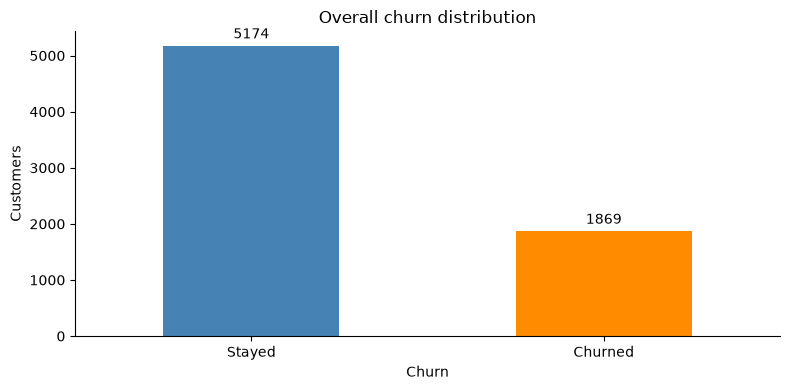

Overall churn rate: 26.54%


In [4]:
counts = data['Churn'].value_counts().sort_index()
ax = counts.plot.bar(rot=0, color=['steelblue', 'darkorange'])
ax.set_xticklabels(['Stayed', 'Churned'])
ax.set_ylabel('Customers')
ax.set_title('Overall churn distribution')
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()
print(f"Overall churn rate: {data['Churn'].mean():.2%}")

1,869 customers churned (26.54%), compared with 5,174 who stayed. A model that always predicts stayed would already achieve 73.46% accuracy, so accuracy alone is insufficient.

In [5]:
def plot_churn_rate(column, title):
    summary = data.groupby(column)['Churn'].agg(['mean', 'count'])
    display(summary.rename(columns={'mean': 'churn_rate', 'count': 'customers'}))
    ax = (summary['mean'] * 100).plot.barh(color='steelblue')
    ax.set_xlim(0, 60)
    ax.set_xlabel('Churn rate (%)')
    ax.set_ylabel('')
    ax.set_title(title)
    ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
    plt.tight_layout()
    plt.show()

## 2. Contract type

,churn_rate,customers
Contract,,
Month-to-month,0.427097,3875
One year,0.112695,1473
Two year,0.028319,1695


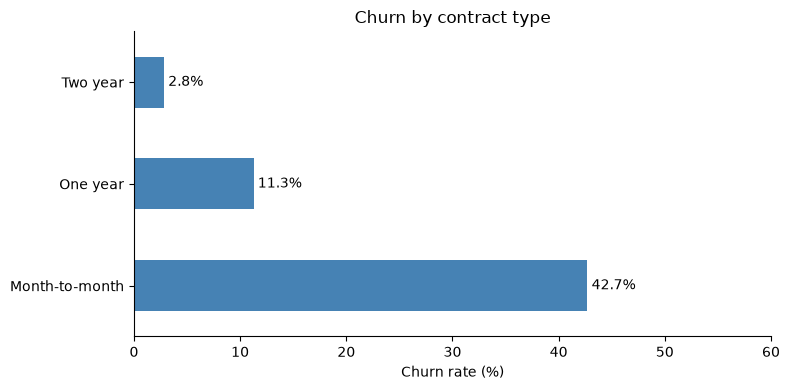

In [6]:
plot_churn_rate('Contract', 'Churn by contract type')

Month-to-month customers have a 42.71% churn rate, compared with 11.27% for one-year and 2.83% for two-year contracts. Contract type has a strong association with churn in this sample.

## 3. Internet service

,churn_rate,customers
InternetService,,
DSL,0.189591,2421
Fiber optic,0.418928,3096
No,0.074050,1526


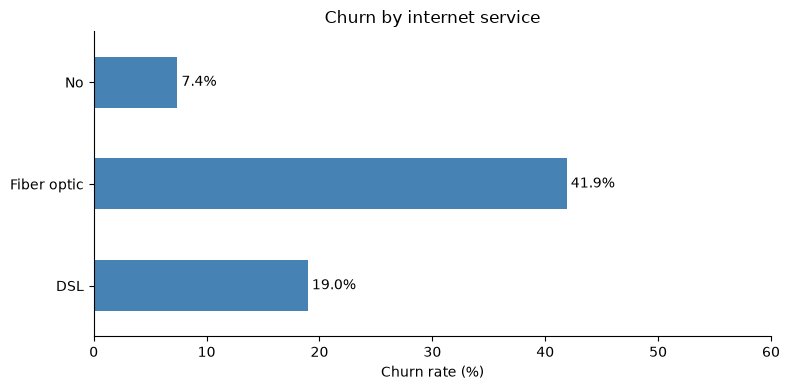

In [7]:
plot_churn_rate('InternetService', 'Churn by internet service')

Fiber-optic customers have higher churn (41.89%) than DSL customers (18.96%). Customers without internet service have the lowest rate (7.40%); these groups may differ in prices, contracts, and other characteristics.

## 4. Payment method

,churn_rate,customers
PaymentMethod,,
Bank transfer (automatic),0.167098,1544
Credit card (automatic),0.152431,1522
Electronic check,0.452854,2365
Mailed check,0.191067,1612


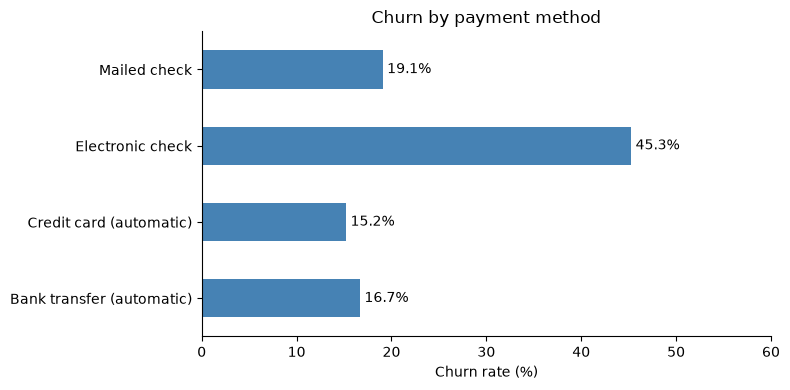

In [8]:
plot_churn_rate('PaymentMethod', 'Churn by payment method')

Electronic-check customers have the highest churn rate (45.29%). Automatic bank transfers and credit-card payments have rates of 16.71% and 15.24%, respectively.

## 5. Senior citizen status

,churn_rate,customers
SeniorCitizen,,
0,0.236062,5901
1,0.416813,1142


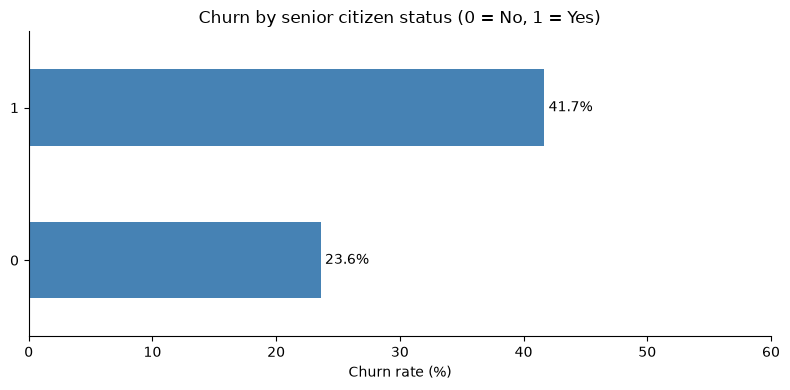

In [9]:
plot_churn_rate('SeniorCitizen', 'Churn by senior citizen status (0 = No, 1 = Yes)')

Senior citizens have a 41.68% churn rate, compared with 23.61% for non-seniors. The senior group is smaller (1,142 versus 5,901 customers), and this comparison does not adjust for other account characteristics.

## 6. Tenure

,mean,count
tenure,,
0–12,0.474382,2186
13–24,0.287109,1024
25–48,0.203890,1594
49–72,0.095132,2239


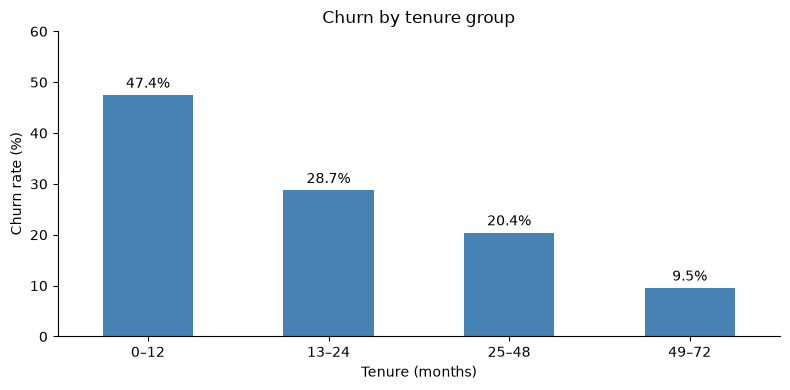

In [10]:
tenure_group = pd.cut(data['tenure'], bins=[-1, 12, 24, 48, 72],
                      labels=['0–12', '13–24', '25–48', '49–72'])
summary = data.groupby(tenure_group, observed=True)['Churn'].agg(['mean', 'count'])
display(summary)
ax = (summary['mean'] * 100).plot.bar(rot=0, color='steelblue')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Churn rate (%)')
ax.set_ylim(0, 60)
ax.set_title('Churn by tenure group')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

Churn is 47.44% among customers with 0–12 months of tenure and 9.51% among those with 49–72 months. The rate decreases across these tenure groups, suggesting that newer customers deserve closer attention.

## 7. Monthly charges

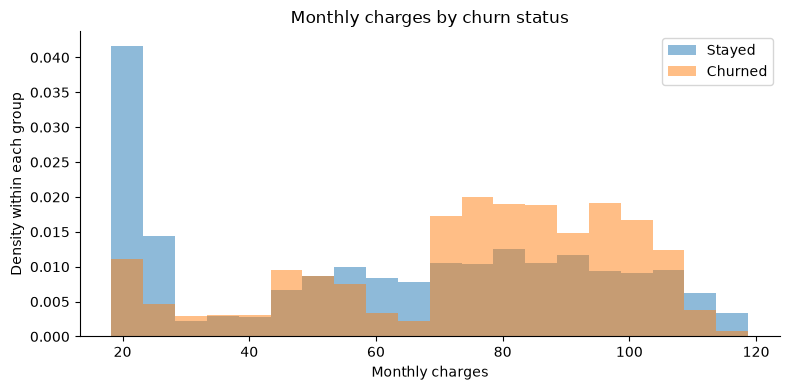

,mean,median,count
Churn,,,
0,61.265124,64.425,5174
1,74.441332,79.650,1869


In [11]:
bins = np.linspace(data['MonthlyCharges'].min(), data['MonthlyCharges'].max(), 21)
fig, ax = plt.subplots()
for churn, label in [(0, 'Stayed'), (1, 'Churned')]:
    charges = data.loc[data['Churn'] == churn, 'MonthlyCharges']
    ax.hist(charges, bins=bins, density=True, alpha=0.5, label=label)
ax.set_xlabel('Monthly charges')
ax.set_ylabel('Density within each group')
ax.set_title('Monthly charges by churn status')
ax.legend()
plt.tight_layout()
plt.show()
display(data.groupby('Churn')['MonthlyCharges'].agg(['mean', 'median', 'count']))

Customers who churned paid higher monthly charges on average (74.44 versus 61.27). The distributions overlap, so a high bill alone is not enough to identify churn; density normalization makes the unequal-sized groups comparable.

## 8. Technical support

,churn_rate,customers
TechSupport,,
No,0.416355,3473
No internet service,0.074050,1526
Yes,0.151663,2044


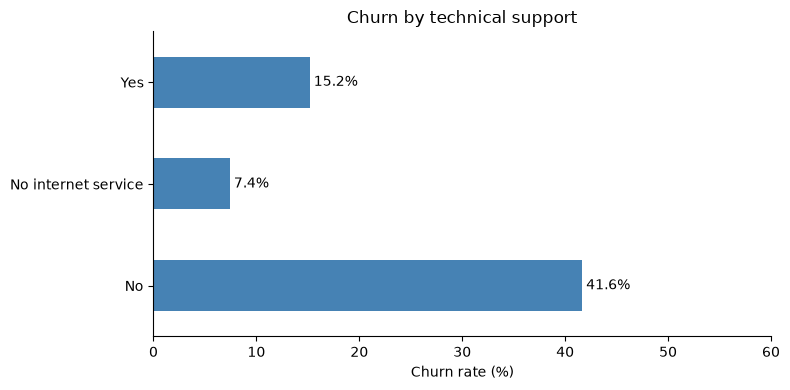

In [12]:
plot_churn_rate('TechSupport', 'Churn by technical support')

Customers without technical support have 41.64% churn, compared with 15.17% for those with support. 'No internet service' is a separate group and should not be interpreted as the same as declining support.

## 9. Online security

,churn_rate,customers
OnlineSecurity,,
No,0.417667,3498
No internet service,0.074050,1526
Yes,0.146112,2019


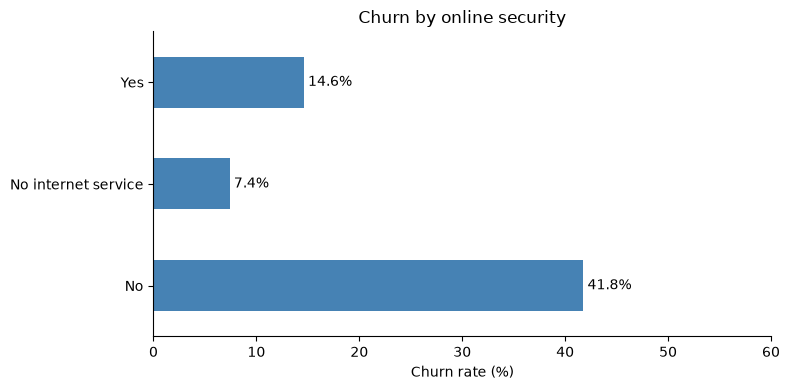

In [13]:
plot_churn_rate('OnlineSecurity', 'Churn by online security')

Customers without online security have 41.77% churn, compared with 14.61% for customers with security. These rates do not establish that adding security would prevent cancellation.

## Key Findings

1. Churn affects 26.54% of customers, making recall, F1, and ROC-AUC important alongside accuracy.
2. Month-to-month contracts have substantially higher churn than one- or two-year contracts.
3. Short-tenure customers churn more often: 47.44% in the first 12 months versus 9.51% at 49–72 months.
4. Churned customers have higher average monthly charges; fiber-optic and electronic-check groups also show elevated churn.
5. Customers without technical support or online security have higher churn than customers with these services. These are associations and may reflect differences in contracts or customer mix.

## Modeling next steps

`main.py` uses an 80/20 split with `random_state=42` and `stratify=y`, preserving similar churn proportions in both sets. Numeric median imputation and scaling, and categorical one-hot encoding, are fitted only on the training set. SeniorCitizen remains a numeric binary indicator. We compare exactly three models using fixed, modest settings and the default 0.5 decision threshold.

This notebook describes the whole dataset. For a stricter future experiment, reserve a final holdout before EDA and select models or thresholds using cross-validation within the training set.